In [11]:
# imports

import pandas as pd
import numpy as np
import os
import seaborn

os.chdir('/Users/douglas/Documents/GitHub/SDOH_Housing_Health_CA/data')
print(os.getcwd())

/Users/douglas/Documents/GitHub/SDOH_Housing_Health_CA/data


In [10]:
# Load full panel data
file_path = '../data/processed/full_panel.csv'
full_panel_df = pd.read_csv(file_path, header=0)
full_panel_df.head()

,fips,county,premature_death_rate,poor_mental_health_days,preventable_hosp_rate,children_in_poverty_pct,low_birthweight_pct,year,median_home_value,median_household_income,income_source,median_multiple
0,6001,Alameda,4885.7,3.3,3786.0,14.3,7.243144,2016,727366.137571,89979.0,1yr,8.083732
1,6003,Alpine,NaN,4.1,NaN,28.2,NaN,2016,354178.372722,62375.0,5yr,5.678210
2,6005,Amador,5775.7,3.5,3607.0,18.6,6.313646,2016,283142.893730,57032.0,5yr,4.964632
3,6007,Butte,7436.8,4.2,4629.0,24.3,5.810629,2016,259383.088246,45177.0,1yr,5.741485
4,6009,Calaveras,7536.8,3.5,3548.0,20.6,4.827586,2016,274860.946378,53502.0,5yr,5.137396


In [12]:
full_panel_df.describe()

,fips,premature_death_rate,poor_mental_health_days,preventable_hosp_rate,children_in_poverty_pct,low_birthweight_pct,year,median_home_value,median_household_income,median_multiple
count,522.000000,504.000000,522.000000,517.000000,522.000000,513.000000,522.000000,5.220000e+02,482.000000,482.000000
mean,6058.000000,6695.972995,4.240015,3205.746615,18.776437,6.586286,2020.000000,5.132549e+05,74273.831950,6.452715
std,33.513454,2064.490679,0.645316,1084.203936,7.299489,0.793038,2.584466,3.042935e+05,24303.488881,1.871963
min,6001.000000,3133.003305,2.879073,921.000000,5.500000,4.483612,2016.000000,1.114962e+05,35270.000000,2.619685
25%,6029.000000,5002.459693,3.760310,2429.000000,13.000000,6.031819,2018.000000,2.957358e+05,56484.000000,5.117031
50%,6058.000000,6594.034256,4.116067,3078.000000,18.200000,6.451613,2020.000000,4.143988e+05,67419.500000,5.967431
75%,6087.000000,7892.101875,4.682376,3808.000000,23.775000,6.976612,2022.000000,6.290468e+05,87700.250000,7.713978
max,6115.000000,15509.465353,6.238212,6648.000000,38.000000,10.055866,2024.000000,1.642988e+06,168154.000000,11.716973


## Descriptive Statistics — Key Observations

Descriptive statistics of the dataset reveal the following notable patterns:

- **Median Multiple:** Mean of 6.45 and median of 5.97 indicate slight right 
  skew driven by extreme high values. The max of 11.72 is nearly four times 
  Demographia's affordability threshold of 3.0. The full range (2.62–11.72) 
  provides meaningful variation for regression analysis despite California's 
  overall bias toward unaffordability. Note: count is 482 rather than 522 due 
  to missing 2020 income data (COVID-19 ACS suspension).

- **Premature Death Rate (per 100,000):** Mean of 6,696 and median of 6,594 
  suggest a relatively symmetrical distribution. The maximum value of 15,509 
  warrants investigation. A nearly five-fold difference between minimum and 
  maximum values indicates substantial county-level variation. Count is 504 
  due to data suppression in Alpine and Sierra counties.

- **Preventable Hospitalization Rate:** A 7.2-fold difference between minimum 
  (921) and maximum (6,648) indicates significant variation. The maximum value 
  warrants investigation.

- **Children in Poverty:** A 6.9-fold difference between minimum and maximum 
  values reflects substantial economic disparity across California counties.






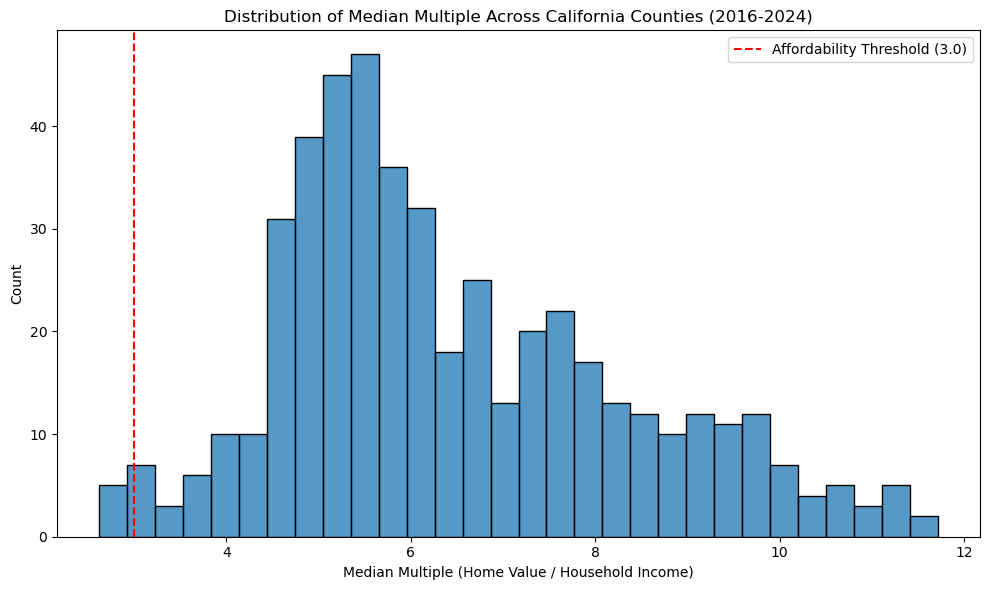

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=full_panel_df, x='median_multiple', bins=30, ax=ax)
ax.set_title('Distribution of Median Multiple Across California Counties (2016-2024)')
ax.set_xlabel('Median Multiple (Home Value / Household Income)')
ax.set_ylabel('Count')
ax.axvline(x=3.0, color='red', linestyle='--', label='Affordability Threshold (3.0)')
ax.legend()
plt.tight_layout()
plt.show()



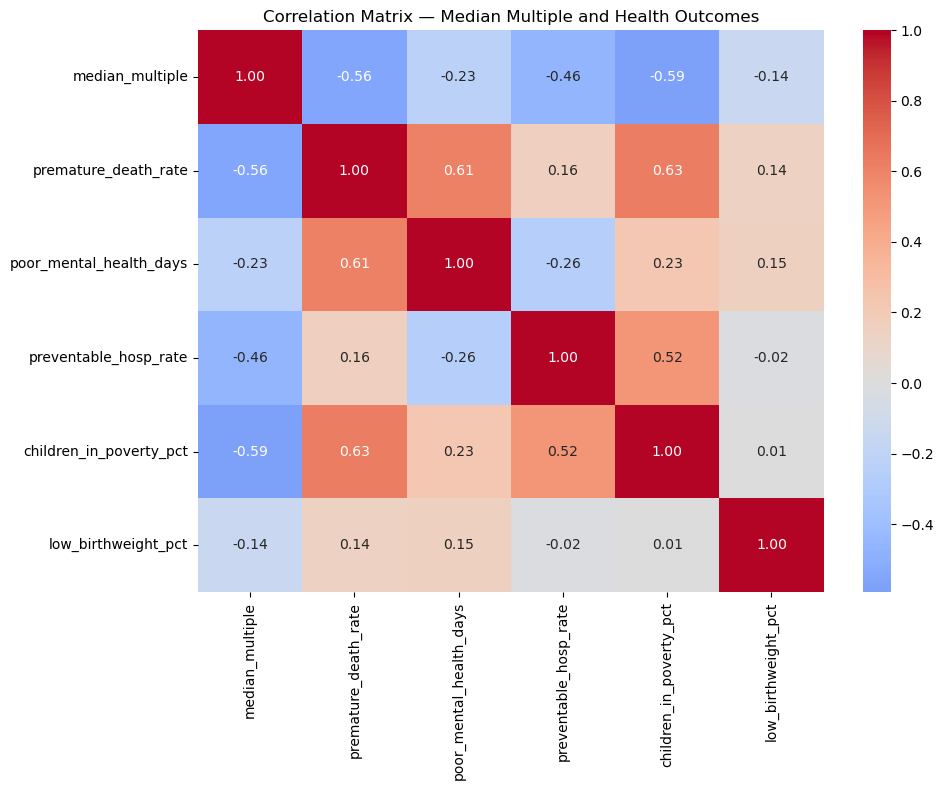

In [16]:
# Correlation matrix — Median Multiple vs outcome variables
corr_cols = ['median_multiple', 'premature_death_rate', 'poor_mental_health_days', 
             'preventable_hosp_rate', 'children_in_poverty_pct', 'low_birthweight_pct']

corr_matrix = full_panel_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=ax)
ax.set_title('Correlation Matrix — Median Multiple and Health Outcomes')
plt.tight_layout()
plt.show()